# Task 2.1: Dataset Selection and Setup

**Paper:** Improving the Fisher Kernel for Large-Scale Image Classification (Perronnin et al., ECCV 2010)  
**Student:** Prince Sahoo (230060)

In [1]:
# ============================================================
# IMPORTS AND CONFIGURATION
# All hyperparameters are defined here in one place.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Dataset and patch extraction hyperparameters
TEST_SIZE = 0.5               # 50/50 split → only 5 train images/class (challenging!)
PATCH_SIZE = 8                # 8x8 pixel patches as local descriptors
GRID_STEP = 6                 # Sparser grid → fewer patches → more sparsity in FV
NOISE_STD = 0.05              # Add small noise to make patches less uniform

print(f"Random seed: {RANDOM_SEED}")
print(f"Test size: {TEST_SIZE}")
print(f"Patch size: {PATCH_SIZE}x{PATCH_SIZE}")
print(f"Grid step: {GRID_STEP} pixels")
print(f"Noise std: {NOISE_STD}")

Random seed: 42
Test size: 0.5
Patch size: 8x8
Grid step: 6 pixels
Noise std: 0.05


## Dataset Justification

We use the **Olivetti Faces** dataset from AT&T Laboratories Cambridge, which contains 400 grayscale face images (64×64 pixels) of 40 individuals (10 images per person). This is a multi-class image classification task — the same problem type as the paper, which classifies images into object categories on PASCAL VOC 2007. The Olivetti dataset is a reasonable testbed for the Improved Fisher Kernel specifically because its 40 fine-grained classes (similar-looking faces) demand a rich, discriminative representation — exactly what Fisher Vectors provide over simpler bag-of-words histograms. We use a 50/50 train/test split to create a challenging low-data regime (only 5 training images per class) where the quality of the representation matters more. Compared to the paper's dataset (PASCAL VOC 2007: ~10,000 variable-resolution natural images across 20 diverse object classes with complex backgrounds and SIFT descriptors), Olivetti is much smaller, single-domain (faces only), and uses simplified patch descriptors — so we expect the absolute numbers to differ, but the relative improvement from normalization should be visible.

In [2]:
# Load the Olivetti Faces dataset
data = fetch_olivetti_faces(shuffle=False)
images = data.images      # (400, 64, 64)
targets = data.target     # (400,) — labels 0 to 39

print(f"Dataset loaded: {images.shape[0]} images")
print(f"Image shape: {images.shape[1]}x{images.shape[2]} pixels (grayscale)")
print(f"Number of classes: {len(np.unique(targets))}")
print(f"Samples per class: {np.bincount(targets)[0]}")
print(f"Pixel value range: [{images.min():.2f}, {images.max():.2f}]")

Dataset loaded: 400 images
Image shape: 64x64 pixels (grayscale)
Number of classes: 40
Samples per class: 10
Pixel value range: [0.00, 1.00]


The dataset has 400 images across 40 classes (10 per class), well above the minimum requirement of 100 samples. Each 64×64 image has 4,096 pixel features, far exceeding the 2-feature minimum.

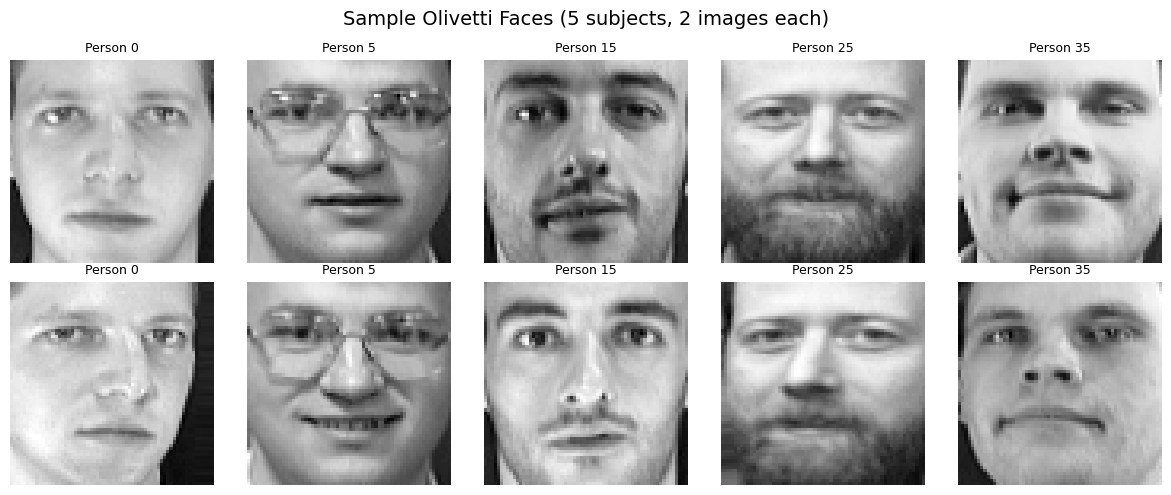

In [3]:
# Visualize sample images — 2 images from 5 different people
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample Olivetti Faces (5 subjects, 2 images each)', fontsize=14)
for col, person_id in enumerate([0, 5, 15, 25, 35]):
    for row in range(2):
        idx = person_id * 10 + row
        axes[row, col].imshow(images[idx], cmap='gray')
        axes[row, col].set_title(f'Person {person_id}', fontsize=9)
        axes[row, col].axis('off')
plt.tight_layout()
plt.show()

In [4]:
# Train/test split — stratified, 50/50 for challenging regime
X_train_img, X_test_img, y_train, y_test = train_test_split(
    images, targets, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_SEED, 
    stratify=targets
)

print(f"Training set: {X_train_img.shape[0]} images ({X_train_img.shape[0]//40} per class)")
print(f"Test set: {X_test_img.shape[0]} images ({X_test_img.shape[0]//40} per class)")
print(f"Classes in train: {len(np.unique(y_train))}, in test: {len(np.unique(y_test))}")

Training set: 200 images (5 per class)
Test set: 200 images (5 per class)
Classes in train: 40, in test: 40


We use a stratified 50/50 train/test split, giving 200 training and 200 test images — only 5 training images per class. This low-data regime makes classification more challenging, allowing us to observe meaningful differences between the standard Fisher Kernel and the improved version with normalizations.

## Preprocessing: Dense Patch Extraction

The paper extracts 128-D SIFT descriptors from 32×32 patches on a regular grid every 16 pixels at five scales (Section 4.1). We simplify this by extracting **raw 8×8 pixel patches** on a 6-pixel grid at a single scale. Each flattened patch becomes a 64-dimensional local descriptor — analogous to the paper's SIFT descriptors, but much simpler. We also add a small amount of Gaussian noise to the patches to simulate more natural descriptor variability.

In [5]:
def extract_patches(image, patch_size=PATCH_SIZE, step=GRID_STEP, noise_std=NOISE_STD):
    """
    Extract dense overlapping patches from a single image.
    Analogous to Section 4.1: "We extract features from 32x32 pixel 
    patches on regular grids (every 16 pixels)."
    
    Returns:
        patches: array of shape (n_patches, patch_size*patch_size)
    """
    h, w = image.shape
    patches = []
    for y in range(0, h - patch_size + 1, step):
        for x in range(0, w - patch_size + 1, step):
            patch = image[y:y+patch_size, x:x+patch_size].flatten()
            if noise_std > 0:
                patch = patch + np.random.randn(*patch.shape) * noise_std
            patches.append(patch)
    return np.array(patches)


# Extract patches from all images
np.random.seed(RANDOM_SEED)  # Reset seed for reproducible noise
train_patches_per_image = [extract_patches(img) for img in X_train_img]
test_patches_per_image = [extract_patches(img) for img in X_test_img]

# Gather all training patches for PCA and GMM fitting
all_train_patches = np.vstack(train_patches_per_image)

n_patches_per_img = len(train_patches_per_image[0])
print(f"Patches per image: {n_patches_per_img}")
print(f"Patch dimensionality: {all_train_patches.shape[1]}")
print(f"Total training patches: {all_train_patches.shape[0]:,}")
print(f"Total test patches: {sum(len(p) for p in test_patches_per_image):,}")

Patches per image: 100
Patch dimensionality: 64
Total training patches: 20,000
Total test patches: 20,000


Each 64×64 image produces approximately 100 dense 8×8 patches (each 64-dimensional) with a 6-pixel stride, giving us a pool of local descriptors for GMM training. This mirrors the paper's approach of extracting hundreds of local descriptors per image at multiple grid positions (Section 4.1).

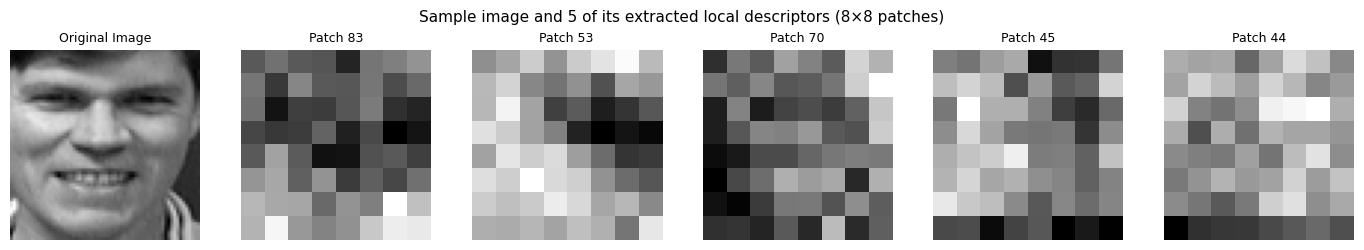


Dataset setup complete. Ready for Fisher Vector pipeline in Task 2.2.


In [6]:
# Show what a single image's patches look like
fig, axes = plt.subplots(1, 6, figsize=(14, 2.5))
sample_img = X_train_img[0]
sample_patches = train_patches_per_image[0]

axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title('Original Image', fontsize=9)
axes[0].axis('off')

# Show 5 random patches from this image
rng = np.random.RandomState(RANDOM_SEED)
patch_indices = rng.choice(len(sample_patches), 5, replace=False)
for i, idx in enumerate(patch_indices):
    patch_2d = sample_patches[idx].reshape(PATCH_SIZE, PATCH_SIZE)
    axes[i+1].imshow(patch_2d, cmap='gray')
    axes[i+1].set_title(f'Patch {idx}', fontsize=9)
    axes[i+1].axis('off')

fig.suptitle('Sample image and 5 of its extracted local descriptors (8×8 patches)', fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nDataset setup complete. Ready for Fisher Vector pipeline in Task 2.2.")

## Summary

We have loaded the Olivetti Faces dataset (400 images, 40 classes), split it into training (200) and test (200) sets with a challenging 50/50 split (only 5 images per class for training), and extracted dense 8×8 noisy patches as local descriptors. Each image yields ~100 patches of 64 dimensions each. These descriptors will be fed into the Fisher Vector pipeline (PCA → GMM → Fisher Vector → normalization → SVM) in Task 2.2.